In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
dfsal = pd.read_csv("D:\DATASETS\Classification-Datasets\Kmeans\income.csv")

In [5]:
dfsal

,Name,Age,Income($)
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000
5,Gautam,39,155000
6,David,41,160000
7,Andrea,38,162000
8,Brad,36,156000
9,Angelina,35,130000


In [6]:
dfsal.shape

(22, 3)

In [7]:
dfsal.columns

Index(['Name', 'Age', 'Income($)'], dtype='object')

In [8]:
dfsal.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Name       22 non-null     object
 1   Age        22 non-null     int64 
 2   Income($)  22 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 660.0+ bytes


In [10]:
dfsal.drop("Name", axis = 1)

,Age,Income($)
0,27,70000
1,29,90000
2,29,61000
3,28,60000
4,42,150000
5,39,155000
6,41,160000
7,38,162000
8,36,156000
9,35,130000


In [11]:
dfsal.drop("Name", axis = 1, inplace = True)

In [12]:
dfsal

,Age,Income($)
0,27,70000
1,29,90000
2,29,61000
3,28,60000
4,42,150000
5,39,155000
6,41,160000
7,38,162000
8,36,156000
9,35,130000


In [13]:
dfsal["Age"].describe()

count    22.000000
mean     34.818182
std       5.901060
min      26.000000
25%      29.000000
50%      36.500000
75%      39.750000
max      43.000000
Name: Age, dtype: float64

In [14]:
dfsal["Income($)"].describe()

count        22.000000
mean      90431.818182
std       43505.964412
min       45000.000000
25%       58500.000000
50%       67500.000000
75%      135250.000000
max      162000.000000
Name: Income($), dtype: float64

In [15]:
dfsal.head()

,Age,Income($)
0,27,70000
1,29,90000
2,29,61000
3,28,60000
4,42,150000


In [16]:
import warnings

In [17]:
warnings.filterwarnings("ignore")

In [18]:
from sklearn.cluster import KMeans

In [20]:
for i in range(1,11):
    km = KMeans(n_clusters= i)
    km.fit_predict(dfsal)
    wc = km.inertia_
    print(i, "==>", np.round(wc) )

1 ==> 39748148459.0
2 ==> 3318233941.0
3 ==> 1606229738.0
4 ==> 843929723.0
5 ==> 296500418.0
6 ==> 242500337.0
7 ==> 188050328.0
8 ==> 153467002.0
9 ==> 99466934.0
10 ==> 68133458.0


In [21]:
wcss = []
for i in range(1,11):
    km = KMeans(n_clusters= i)
    km.fit_predict(dfsal)
    wc = km.inertia_
    wcss.append(np.round(wc))
print(wcss)

[np.float64(39748148459.0), np.float64(3318233941.0), np.float64(1577046059.0), np.float64(814746044.0), np.float64(296500418.0), np.float64(242500337.0), np.float64(177967004.0), np.float64(128133608.0), np.float64(95133612.0), np.float64(68133458.0)]


In [22]:
dfsal.columns

Index(['Age', 'Income($)'], dtype='object')

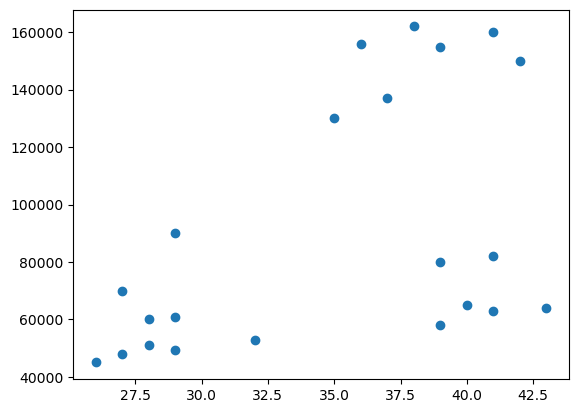

In [23]:
plt.scatter(dfsal["Age"], dfsal["Income($)"])

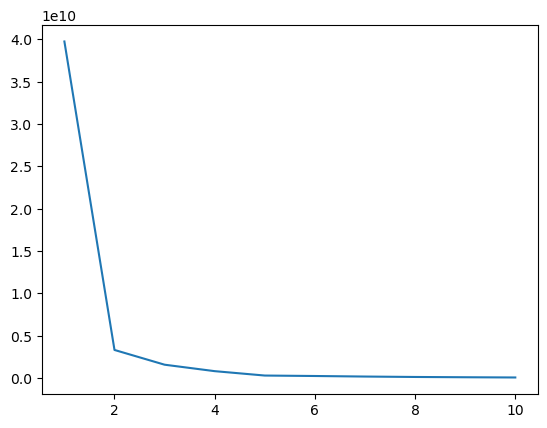

In [24]:
plt.plot(range(1,11), wcss)
plt.show()

In [27]:
dfsal

,Age,Income($)
0,27,70000
1,29,90000
2,29,61000
3,28,60000
4,42,150000
5,39,155000
6,41,160000
7,38,162000
8,36,156000
9,35,130000


In [29]:
data = dfsal.values

In [30]:
type(dfsal)

pandas.core.frame.DataFrame

In [31]:
type(data)

numpy.ndarray

In [25]:
km2 = KMeans(n_clusters=2)

In [26]:
km2

KMeans(n_clusters=2)

In [33]:
y_pred = km2.fit_predict(data)

In [34]:
y_pred

array([1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
      dtype=int32)

In [35]:
y_pred == 0

array([False, False, False, False,  True,  True,  True,  True,  True,
        True,  True, False, False, False, False, False, False, False,
       False, False, False, False])

In [36]:
data[y_pred == 0]

array([[    42, 150000],
       [    39, 155000],
       [    41, 160000],
       [    38, 162000],
       [    36, 156000],
       [    35, 130000],
       [    37, 137000]])

In [37]:
data[y_pred == 0,0]

array([42, 39, 41, 38, 36, 35, 37])

In [38]:
data[y_pred == 0,1]

array([150000, 155000, 160000, 162000, 156000, 130000, 137000])

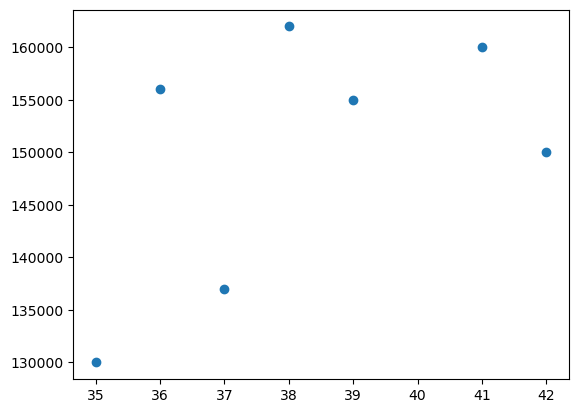

In [39]:
plt.scatter(data[y_pred == 0,0], data[y_pred == 0,1])
plt.show()

In [40]:
y_pred == 1

array([ True,  True,  True,  True, False, False, False, False, False,
       False, False,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True])

In [41]:
data[y_pred == 1]

array([[   27, 70000],
       [   29, 90000],
       [   29, 61000],
       [   28, 60000],
       [   26, 45000],
       [   27, 48000],
       [   28, 51000],
       [   29, 49500],
       [   32, 53000],
       [   40, 65000],
       [   41, 63000],
       [   43, 64000],
       [   39, 80000],
       [   41, 82000],
       [   39, 58000]])

In [42]:
data[y_pred == 1,0]

array([27, 29, 29, 28, 26, 27, 28, 29, 32, 40, 41, 43, 39, 41, 39])

In [43]:
data[y_pred == 1, 1]

array([70000, 90000, 61000, 60000, 45000, 48000, 51000, 49500, 53000,
       65000, 63000, 64000, 80000, 82000, 58000])

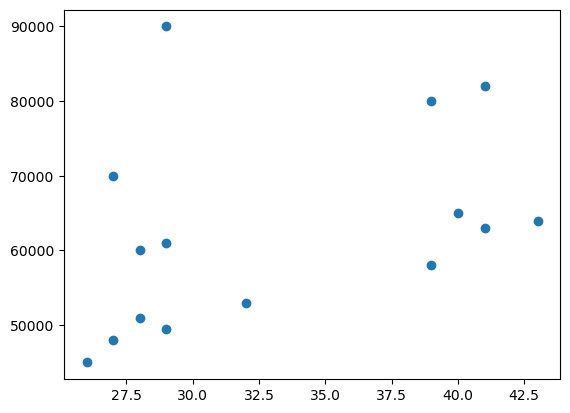

In [44]:
plt.scatter(data[y_pred == 1,0], data[y_pred == 1, 1])
plt.show()

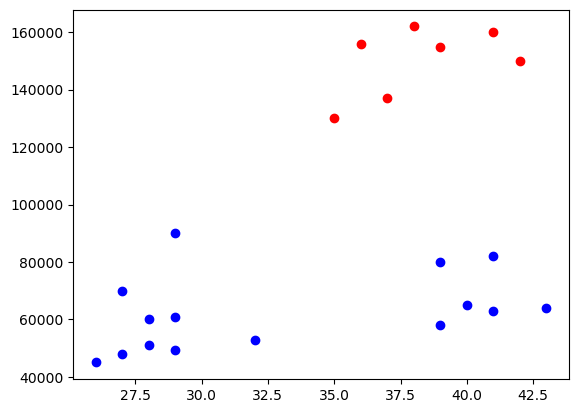

In [45]:
plt.scatter(data[y_pred == 0,0], data[y_pred == 0, 1], color = "red")
plt.scatter(data[y_pred == 1,0], data[y_pred == 1, 1], color = "blue")
plt.show()